In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.spatial.distance import cosine
from sentence_transformers import SentenceTransformer, util
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from lightgbm import LGBMClassifier

# Mount Google Drive để truy cập file dữ liệu
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')

# Cấu hình đồ họa cho trực quan hóa
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Thư mục chứa dữ liệu
base_path = '/content/drive/MyDrive/Intro to AI/Raw Data'
out_dir = '/content/drive/MyDrive/Intro to AI/Processed_Data'
os.makedirs(out_dir, exist_ok=True)

Mounted at /content/drive


# Tiền xử lí dữ liệu

## Làm sạch dữ liệu

### Dataset Review - Maping category

In [2]:
# PHẦN 1: ĐỊNH NGHĨA
# ==============================================================================
# Dictionary
category_mapping_dict = {
    "Category 1": "churches", "Category 2": "resorts", "Category 3": "beaches",
    "Category 4": "parks", "Category 5": "theatres", "Category 6": "museums",
    "Category 7": "malls", "Category 8": "zoo", "Category 9": "restaurants",
    "Category 10": "pubs/bars", "Category 11": "local services", "Category 12": "burger/pizza shops",
    "Category 13": "hotels/other lodgings", "Category 14": "juice bars", "Category 15": "art galleries",
    "Category 16": "dance clubs", "Category 17": "swimming pools", "Category 18": "gyms",
    "Category 19": "bakeries", "Category 20": "beauty & spas", "Category 21": "cafes",
    "Category 22": "view points", "Category 23": "monuments", "Category 24": "gardens"
}
review_attributes = list(category_mapping_dict.values())

# Các từ khoá nhiễu
NON_TRAVEL_KEYWORDS = [
    'station', 'metro', 'bus', 'atm', 'bank', 'office', 'hospital', 'residential', 'laundry', 'medical',
    'subway', 'rail', 'train', 'pier', 'airport', 'highway', 'terminal', 'taxi', 'government', 'road',
    'college', 'school', 'home'
]

# ==============================================================================
# PHẦN 2: LÀM SẠCH VÀ ĐỔI TÊN FILE REVIEW RATING THẬT
# ==============================================================================
def clean_review_dataset():
    review_path = os.path.join(base_path, 'travel_review_dataset.csv')
    if not os.path.exists(review_path):
        print("❌ Không tìm thấy file Review!")
        return None

    df_review = pd.read_csv(review_path)

    # Đổi tên cột User thành userId cho đồng nhất
    if 'User' in df_review.columns:
        df_review = df_review.rename(columns={'User': 'userId'})

    # Đổi tên các cột từ Category 1, 2... thành chữ tiếng Anh
    df_review = df_review.rename(columns=category_mapping_dict)

    # ĐIỀU CHỈNH QUAN TRỌNG: Sửa lỗi text bẩn như '2\t2.' khiến ko ép được sang float
    # Lấy danh sách các cột danh mục hiện có (trừ userId và cột rác Unnamed)
    target_cols = [c for c in df_review.columns if c not in ['userId', 'Unnamed: 25']]

    for col in target_cols:
        if df_review[col].dtype == 'object':
            # Loại bỏ ký tự khoảng trắng thừa, tab, xuống dòng ẩn trong chuỗi text
            df_review[col] = df_review[col].astype(str).str.replace(r'[\s\t\n\r]+', '', regex=True)
            # Ép về kiểu số thực, điền NaN cho các ô lỗi phân tách không hợp lệ
            df_review[col] = pd.to_numeric(df_review[col], errors='coerce')

    out_path = os.path.join(out_dir, 'review_cleaned.csv')
    df_review.to_csv(out_path, index=False)
    print(f"✅ Đã chuẩn hóa xong file Review và lưu tại: {out_path}")
    return df_review

# Thực thi xử lý tập Review trước
df_review_cleaned = clean_review_dataset()

✅ Đã chuẩn hóa xong file Review và lưu tại: /content/drive/MyDrive/Intro to AI/Processed_Data/review_cleaned.csv


### Dataset Foursquare - Phân loại và lọc

In [3]:
# PHẦN 3: LỌC FOURSQUARE VÀ MAPPING NÂNG CẤP (RULE-BASED + EMBEDDING)
# ==============================================================================
def clean_and_map_foursquare():
    foursquare_path = os.path.join(base_path, 'foursquare_data.csv')
    if not os.path.exists(foursquare_path):
        print("❌ Không tìm thấy file Foursquare!")
        return None

    df_4s = pd.read_csv(foursquare_path)
    col_name = 'venueCategory'

    # Chuẩn hóa thời gian ngay từ bước này để phục vụ trực quan hóa
    df_4s['utcTimestamp'] = pd.to_datetime(df_4s['utcTimestamp'], format='%a %b %d %H:%M:%S +0000 %Y', errors='coerce')
    df_4s = df_4s.sort_values(by='utcTimestamp').reset_index(drop=True)

    # 1. Loại bỏ các địa điểm không mang tính du lịch
    initial_shape = df_4s.shape[0]
    df_4s = df_4s[~df_4s[col_name].str.lower().str.contains('|'.join(NON_TRAVEL_KEYWORDS), na=False)]
    print(f"🗑️ Đã xóa {initial_shape - df_4s.shape[0]} dòng dữ liệu phi du lịch (Train Station, ATM,...)")

    # 2. Định nghĩa luật ép danh mục thủ công để cứu các điểm du lịch xịn bị sót
    manual_travel_fix = {
        "bridge": "view points", "arcade": "theatres", "event space": "theatres",
        "aquarium": "zoo", "castle": "monuments", "historic": "museums",
        "shrine": "churches", "temple": "churches", "deli": "restaurants",
        "bodega": "restaurants", "fair": "parks", "hot dog": "burger/pizza shops",
        "wings joint": "restaurants", "gastropub": "pubs/bars"
    }

    # 3. MAPPING CÓ NGƯỠNG CHẶN SIMILARITY KẾT HỢP AI
    unique_cats = df_4s[col_name].unique()
    model = SentenceTransformer('all-MiniLM-L6-v2')
    attr_embeddings = model.encode(review_attributes, convert_to_tensor=True)

    cat_map = {}
    for cat in unique_cats:
        cat_lower = str(cat).lower()

        matched_manually = False
        for keyword, target_parent in manual_travel_fix.items():
            if keyword in cat_lower:
                cat_map[cat] = target_parent
                matched_manually = True
                break

        if not matched_manually:
            cat_embedding = model.encode(str(cat), convert_to_tensor=True)
            scores = util.cos_sim(cat_embedding, attr_embeddings).cpu().numpy()[0]

            best_match_idx = np.argmax(scores)
            best_score = scores[best_match_idx]

            if best_score < 0.33:
                cat_map[cat] = "local services"
            else:
                cat_map[cat] = review_attributes[best_match_idx]

    df_4s['parent_category'] = df_4s[col_name].map(cat_map)

    # 4. LỌC BỎ USER CÓ DƯỚI 100 DÒNG CHECK-IN
    initial_users = df_4s['userId'].nunique()
    initial_rows_before_user_filter = df_4s.shape[0]

    user_activity_counts = df_4s['userId'].value_counts()
    active_users = user_activity_counts[user_activity_counts >= 100].index
    df_4s = df_4s[df_4s['userId'].isin(active_users)].reset_index(drop=True)

    print(f"\n✂️ [LỌC USER THƯA THỚT]:")
    print(f"   - Đã loại bỏ {initial_users - df_4s['userId'].nunique()} users có dưới 100 check-ins.")
    print(f"   - Hệ thống đã xóa {initial_rows_before_user_filter - df_4s.shape[0]} dòng tương ứng.")
    print(f"   - Số lượng User xịn giữ lại: {df_4s['userId'].nunique()} users.\n")

    out_path = os.path.join(out_dir, 'foursquare_mapped.csv')
    df_4s.to_csv(out_path, index=False)
    print(f"✅ Đã xử lý xong file Foursquare và lưu tại: {out_path}")
    return df_4s

# Thực thi xử lý tập Foursquare
df_foursquare_mapped = clean_and_map_foursquare()

🗑️ Đã xóa 298663 dòng dữ liệu phi du lịch (Train Station, ATM,...)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


✂️ [LỌC USER THƯA THỚT]:
   - Đã loại bỏ 1262 users có dưới 100 check-ins.
   - Hệ thống đã xóa 79031 dòng tương ứng.
   - Số lượng User xịn giữ lại: 1031 users.

✅ Đã xử lý xong file Foursquare và lưu tại: /content/drive/MyDrive/Intro to AI/Processed_Data/foursquare_mapped.csv


### Trực quan hoá Foursquare gốc


📊 ĐANG KHỞI TẠO CÁC BIỂU ĐỒ KHẢO SÁT DỮ LIỆU GỐC (PRE-IMPUTATION)...


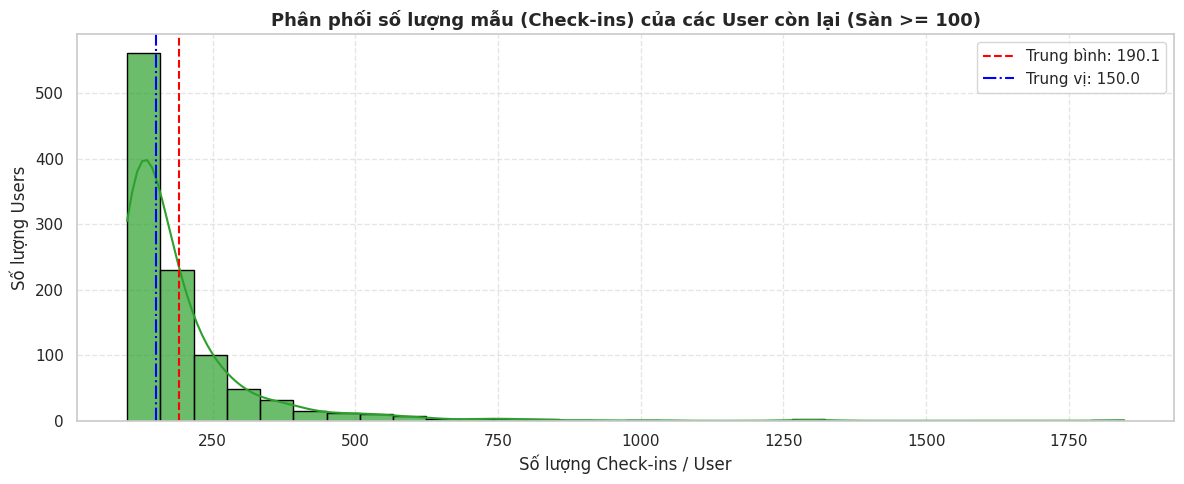

/tmp/ipykernel_2040/1985534426.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_venue_cats.values, y=top_venue_cats.index, palette='viridis', edgecolor='black')


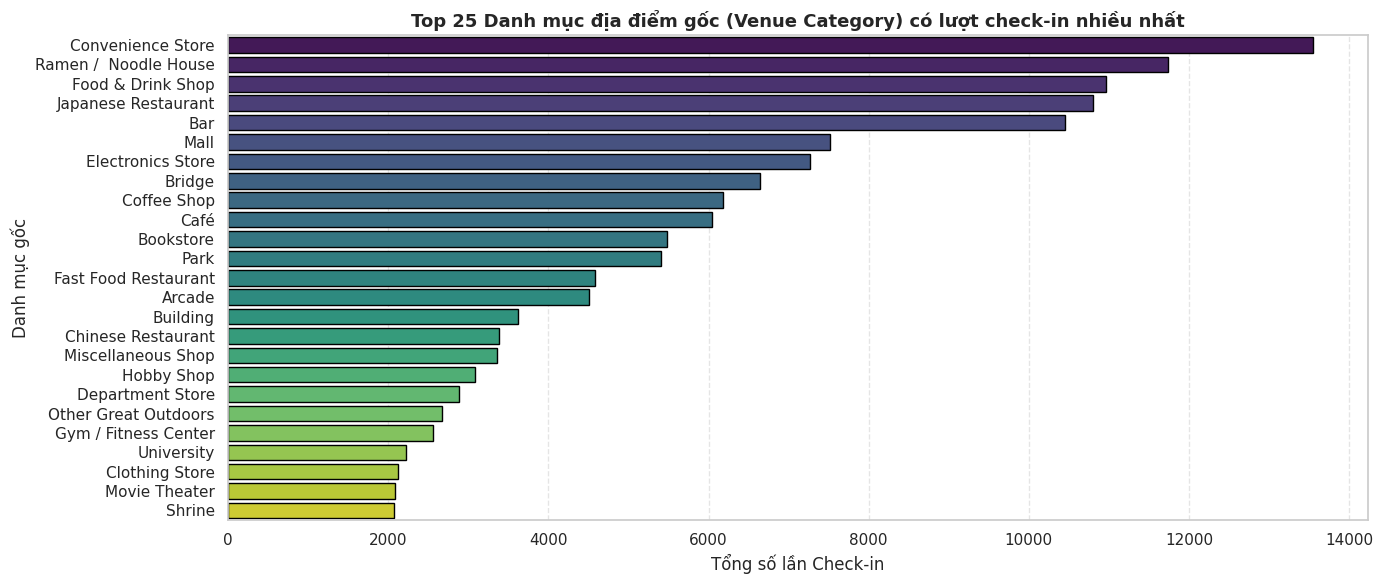

/tmp/ipykernel_2040/1985534426.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=parent_cats.values, y=parent_cats.index, palette='plasma', edgecolor='black')


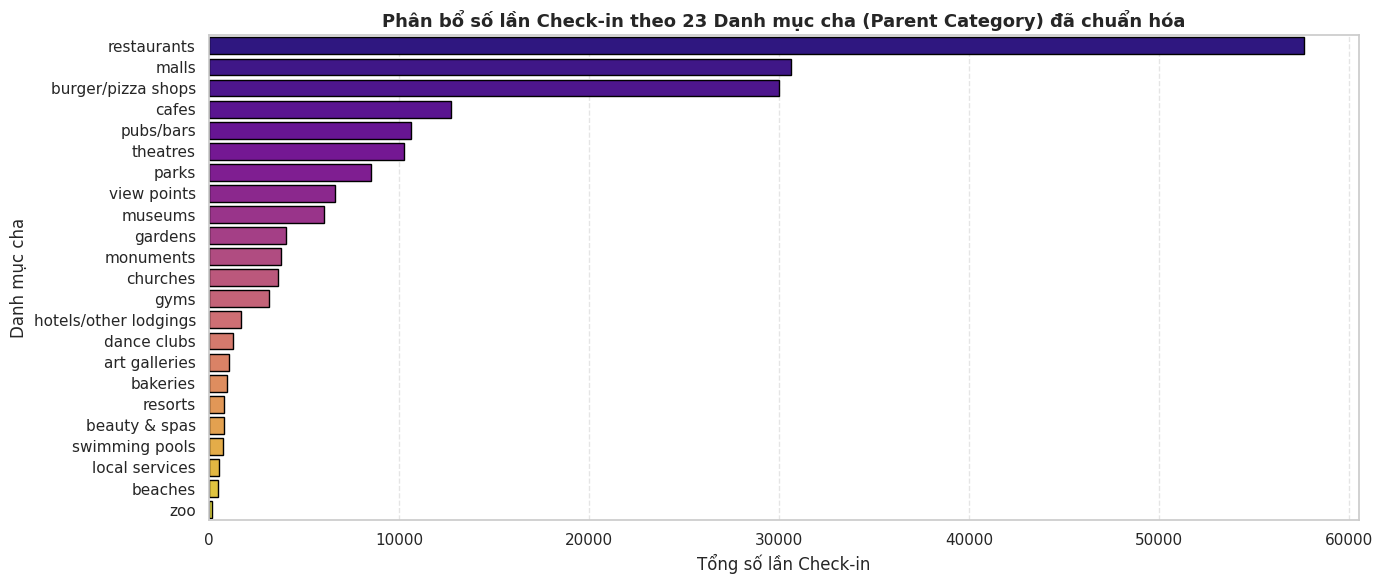

🎯 Đã chọn User tích cực nhất hệ thống: USER ID: 822 với 1847 check-ins.


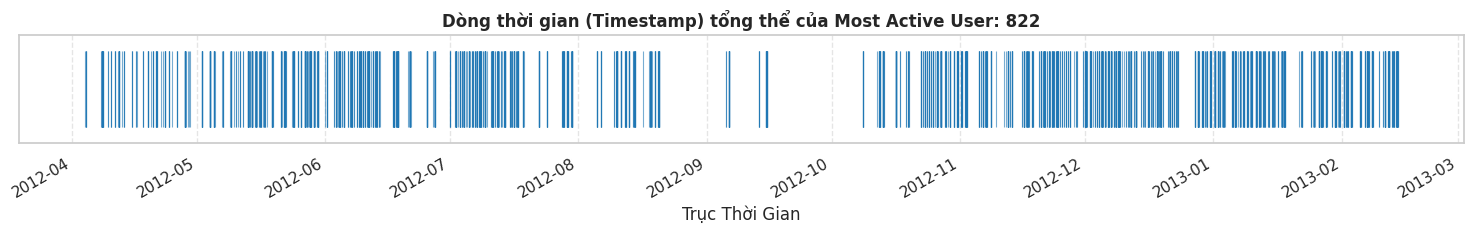

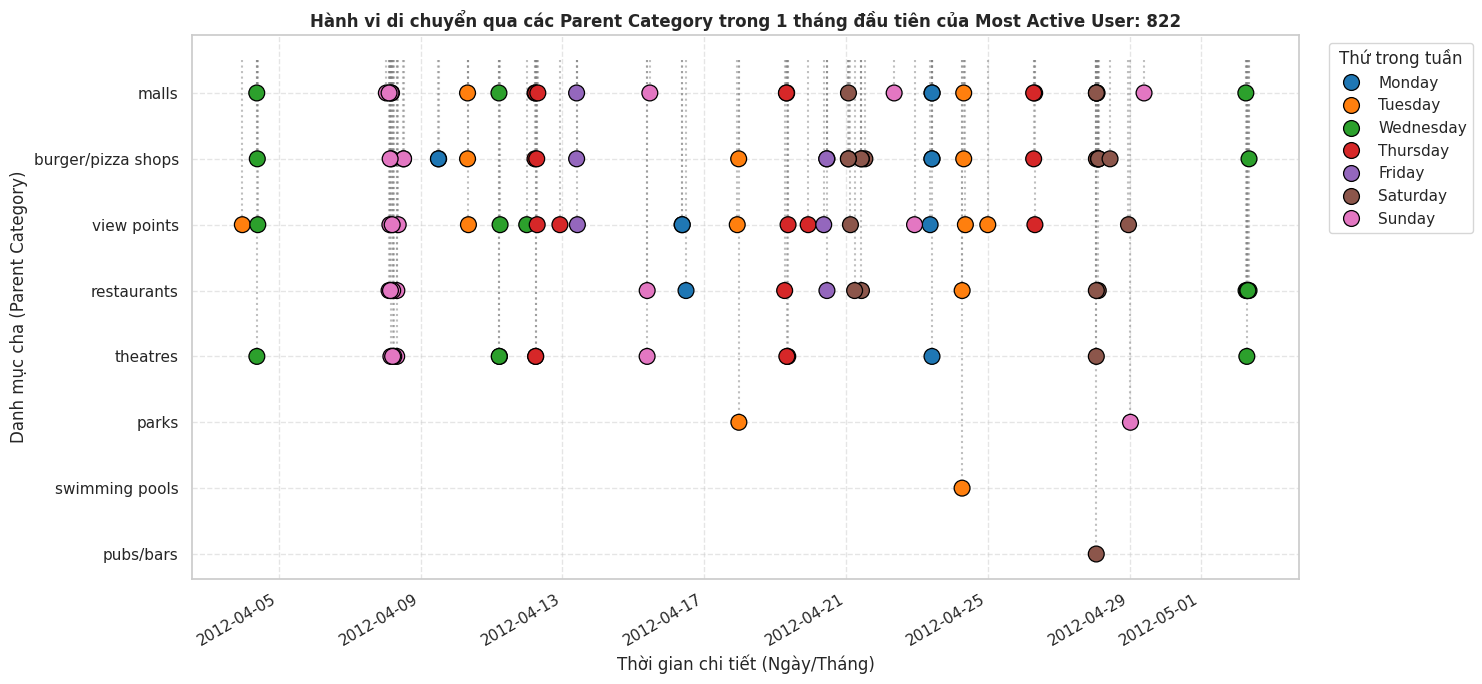

💾 Tất cả 5 biểu đồ khảo sát gốc đã được lưu gọn gàng tại: /content/drive/MyDrive/Intro to AI/Plots


In [4]:
# TRỰC QUAN HÓA TOÀN CỤC VÀ KHẢO SÁT USER TÍCH CỰC NHẤT (PRE-IMPUTATION)
# ==============================================================================
def visualize_pre_imputation_data(df_four_square):
    if df_four_square is None or df_four_square.empty:
        print("⚠️ Dữ liệu trống, không thể trực quan hóa!")
        return

    print("\n📊 ĐANG KHỞI TẠO CÁC BIỂU ĐỒ KHẢO SÁT DỮ LIỆU GỐC (PRE-IMPUTATION)...")
    img_out_dir = '/content/drive/MyDrive/Intro to AI/Plots'
    os.makedirs(img_out_dir, exist_ok=True)

    # --------------------------------------------------------------------------
    # BIỂU ĐỒ 1: PHÂN PHỐI SỐ LƯỢNG MẪU (CHECK-INS) CỦA CÁC USER CÒN LẠI
    # --------------------------------------------------------------------------
    plt.figure(figsize=(12, 5))
    user_counts = df_four_square['userId'].value_counts()

    sns.histplot(user_counts, bins=30, kde=True, color='#2ca02c', edgecolor='black', alpha=0.7)
    plt.axvline(user_counts.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Trung bình: {user_counts.mean():.1f}')
    plt.axvline(user_counts.median(), color='blue', linestyle='-.', linewidth=1.5, label=f'Trung vị: {user_counts.median():.1f}')

    plt.title('Phân phối số lượng mẫu (Check-ins) của các User còn lại (Sàn >= 100)', fontsize=13, fontweight='bold')
    plt.xlabel('Số lượng Check-ins / User')
    plt.ylabel('Số lượng Users')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(img_out_dir, '01_foursquare_user_sample_distribution.png'))
    plt.show()

    # --------------------------------------------------------------------------
    # BIỂU ĐỒ 2: THỐNG KÊ SỐ LẦN CHECK-IN THEO DANH MỤC DU LỊCH GỐC (TOP 25)
    # --------------------------------------------------------------------------
    plt.figure(figsize=(14, 6))
    top_venue_cats = df_four_square['venueCategory'].value_counts().head(25)

    sns.barplot(x=top_venue_cats.values, y=top_venue_cats.index, palette='viridis', edgecolor='black')
    plt.title('Top 25 Danh mục địa điểm gốc (Venue Category) có lượt check-in nhiều nhất', fontsize=13, fontweight='bold')
    plt.xlabel('Tổng số lần Check-in')
    plt.ylabel('Danh mục gốc')
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(img_out_dir, '02_foursquare_top_venue_categories.png'))
    plt.show()

    # --------------------------------------------------------------------------
    # BIỂU ĐỒ 3: THỐNG KÊ SỐ LẦN CHECK-IN THEO DANH MỤC CHA (PARENT CATEGORY)
    # --------------------------------------------------------------------------
    plt.figure(figsize=(14, 6))
    parent_cats = df_four_square['parent_category'].value_counts()

    sns.barplot(x=parent_cats.values, y=parent_cats.index, palette='plasma', edgecolor='black')
    plt.title('Phân bổ số lần Check-in theo 23 Danh mục cha (Parent Category) đã chuẩn hóa', fontsize=13, fontweight='bold')
    plt.xlabel('Tổng số lần Check-in')
    plt.ylabel('Danh mục cha')
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(img_out_dir, '03_foursquare_parent_categories_distribution.png'))
    plt.show()

    # --------------------------------------------------------------------------
    # THIẾT LẬP LOGIC: TÌM USER TÍCH CỰC NHẤT (MOST ACTIVE USER)
    # --------------------------------------------------------------------------
    most_active_user = user_counts.index[0]  # Lấy userId đứng đầu danh sách value_counts()
    user_df = df_four_square[df_four_square['userId'] == most_active_user].copy()

    print(f"🎯 Đã chọn User tích cực nhất hệ thống: USER ID: {most_active_user} với {len(user_df)} check-ins.")

    # --------------------------------------------------------------------------
    # BIỂU ĐỒ 4: BARCODE TIMELINE (USER TÍCH CỰC NHẤT)
    # --------------------------------------------------------------------------
    plt.figure(figsize=(15, 2.5))
    plt.vlines(user_df['utcTimestamp'], ymin=0, ymax=1, colors='#1f77b4', linewidth=0.8, alpha=0.6)
    plt.title(f'Dòng thời gian (Timestamp) tổng thể của Most Active User: {most_active_user}', fontweight='bold')
    plt.xlabel('Trục Thời Gian')
    plt.gca().get_yaxis().set_visible(False)
    plt.ylim(-0.2, 1.2)
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.savefig(os.path.join(img_out_dir, '04_most_active_user_barcode_timeline.png'))
    plt.show()

    # --------------------------------------------------------------------------
    # BIỂU ĐỒ 5: CHU KỲ TUẦN TRONG 1 THÁNG ĐẦU TIÊN (USER TÍCH CỰC NHẤT)
    # --------------------------------------------------------------------------
    start_date = user_df['utcTimestamp'].min()
    end_date = start_date + pd.Timedelta(days=30)
    month_df = user_df[(user_df['utcTimestamp'] >= start_date) & (user_df['utcTimestamp'] <= end_date)].copy()

    if len(month_df) >= 3:
        month_df['day_of_week'] = month_df['utcTimestamp'].dt.day_name()

        # Sắp xếp thứ tự các ngày trong tuần để hiển thị huyền thoại (legend) cho chuẩn
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        month_df['day_of_week'] = pd.Categorical(month_df['day_of_week'], categories=day_order, ordered=True)
        month_df = month_df.sort_values('day_of_week')

        plt.figure(figsize=(15, 7))
        sns.scatterplot(
            data=month_df,
            x='utcTimestamp',
            y='parent_category',
            hue='day_of_week',
            palette='tab10',
            s=130,
            marker='o',
            edgecolor='black',
            zorder=3
        )
        plt.vlines(month_df['utcTimestamp'], ymin=-0.5, ymax=month_df['parent_category'], colors='gray', linestyle=':', alpha=0.5)
        plt.title(f'Hành vi di chuyển qua các Parent Category trong 1 tháng đầu tiên của Most Active User: {most_active_user}', fontweight='bold')
        plt.xlabel('Thời gian chi tiết (Ngày/Tháng)')
        plt.ylabel('Danh mục cha (Parent Category)')
        plt.legend(title='Thứ trong tuần', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.gcf().autofmt_xdate()
        plt.tight_layout()
        plt.savefig(os.path.join(img_out_dir, '05_most_active_user_temporal_cycle.png'))
        plt.show()
    else:
        print("ℹ️ Dữ liệu tháng đầu của user này quá thưa thớt, bỏ qua biểu đồ chu kỳ tuần.")

    print(f"💾 Tất cả 5 biểu đồ khảo sát gốc đã được lưu gọn gàng tại: {img_out_dir}")

# Gọi hàm chạy trực quan hóa dữ liệu gốc trước khi điền khuyết
# (Truyền dataframe foursquare đã qua bước làm sạch/lọc sàn của bà vào)
visualize_pre_imputation_data(df_foursquare_mapped)

## Điền khuyết dữ liệu

### Đồ thị Elbow

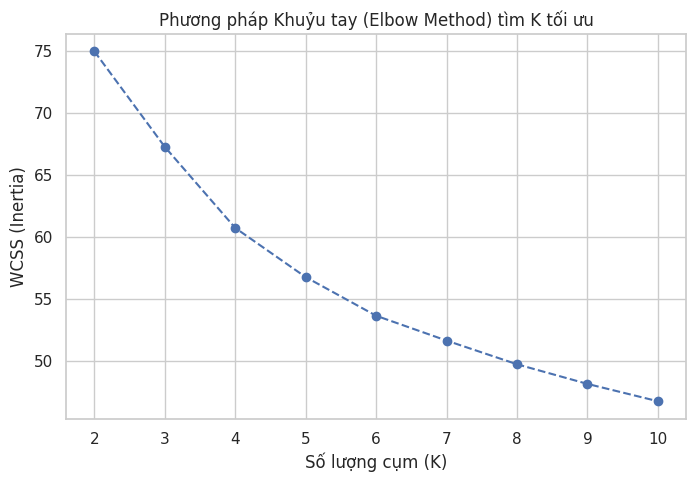

In [5]:
# Chuẩn bị dữ liệu giống trong pipeline của bạn
categories = [c for c in df_review_cleaned.columns if c not in ['userId', 'Unnamed: 25']]
X = df_review_cleaned[categories].fillna(0).values
X_norm = normalize(X, norm='l1', axis=1)

wcss = []
k_range = range(2, 11) # Khảo sát từ 2 đến 10 cụm

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_norm)
    wcss.append(kmeans.inertia_) # Inertia: Tổng bình phương khoảng cách tới tâm cụm

# Vẽ đồ thị Elbow
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Phương pháp Khuỷu tay (Elbow Method) tìm K tối ưu')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### Điền khuyết bằng vector hoá và K-Means

In [6]:
# ==============================================================================
# LUỒNG XỬ LÝ ĐỒNG BỘ & MAPPED NGƯỢC GIỮ NGUYÊN CỘT GỐC (ĐÃ SỬA LỖI CỘT RÁC VÀ BIẾN)
# ==============================================================================
def pipeline_personalized_domain_adaptation(df_review, df_4s, n_clusters=4):
    print("🚀 BẮT ĐẦU LUỒNG XỬ LÝ ĐỒNG BỘ ĐÃ CẢI TIẾN THUỘC TÍNH GỐC...")

    # FIX CHÍ MẠNG: Loại bỏ cả userId và cột rác Unnamed: 25 ra khỏi danh mục đặc trưng
    categories = [c for c in df_review.columns if c not in ['userId', 'Unnamed: 25']]

    # BƯỚC 1: TẠO PROFILE VECTOR MỊN
    review_profiles = df_review[categories].fillna(0).values
    review_profiles_norm = normalize(review_profiles, norm='l1', axis=1)

    foursquare_counts = df_4s.groupby(['userId', 'parent_category']).size().unstack(fill_value=0)
    foursquare_counts = foursquare_counts.reindex(columns=categories, fill_value=0)
    foursquare_profiles_norm = normalize(foursquare_counts.values, norm='l1', axis=1)

    # BƯỚC 2: PHÂN CỤM THEO TÂM CỤM REVIEW
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    review_clusters = kmeans.fit_predict(review_profiles_norm)
    foursquare_clusters = kmeans.predict(foursquare_profiles_norm)

    df_review_clustered = df_review.copy()
    df_review_clustered['cluster'] = review_clusters

    foursquare_counts['cluster'] = foursquare_clusters
    foursquare_user_cluster_map = foursquare_counts[['cluster']].reset_index()

    print(f"✅ Đã đồng bộ phân cụm xong trên không gian Anchor Review.")

    # BƯỚC 3 & 4: HỌC VÀ PHÂN RÃ THEO TỪNG VENUE ĐỊA ĐIỂM CHI TIẾT
    foursquare_item_level_list = []

    for k in range(n_clusters):
        review_in_cluster = df_review_clustered[df_review_clustered['cluster'] == k][categories].values.flatten()
        review_in_cluster = review_in_cluster[~np.isnan(review_in_cluster) & (review_in_cluster > 0)]

        if len(review_in_cluster) == 0:
            continue

        review_sorted_pattern = np.sort(review_in_cluster)

        users_in_foursquare_cluster = foursquare_user_cluster_map[foursquare_user_cluster_map['cluster'] == k]['userId']
        df_4s_sub = df_4s[df_4s['userId'].isin(users_in_foursquare_cluster)]

        if df_4s_sub.empty:
            continue

        # Group-by thu gọn mức Item-level để tính hạng phân vị (percentile rank)
        venue_counts_df = df_4s_sub.groupby(['userId', 'venueId', 'parent_category']).size().reset_index(name='checkin_count')

        counts = venue_counts_df['checkin_count'].values
        ranks = (counts.argsort().argsort() / len(counts))
        indices = (ranks * (len(review_sorted_pattern) - 1)).astype(int)

        venue_counts_df['simulated_rating'] = review_sorted_pattern[indices]
        venue_counts_df['cluster'] = k

        foursquare_item_level_list.append(venue_counts_df)

    # Gộp bảng rating giả lập vĩ mô
    df_simulated_ratings_base = pd.concat(foursquare_item_level_list, ignore_index=True)

    # --------------------------------------------------------------------------
    # ÉP NGƯỢC VỀ BẢNG GỐC: Giữ trọn vẹn cấu trúc file ban đầu
    # --------------------------------------------------------------------------
    print("🔗 Đang tiến hành tích hợp điểm số mới vào cấu trúc bảng Foursquare gốc...")

    # Tiến hành merge kết quả simulated_rating dựa trên cặp định danh (userId, venueId)
    df_foursquare_final_with_all_columns = pd.merge(
        df_4s,
        df_simulated_ratings_base[['userId', 'venueId', 'simulated_rating', 'cluster']],
        on=['userId', 'venueId'],
        how='inner'
    )

    # Xuất file kết quả
    out_path = os.path.join(out_dir, 'foursquare_simulated_ratings.csv')
    df_foursquare_final_with_all_columns.to_csv(out_path, index=False)

    print("\n==================================================")
    print("        📊 BÁO CÁO NGHIỆM THU ĐẦY ĐỦ CÁC CỘT GỐC       ")
    print("==================================================")
    print(f"📁 File đầu ra: {out_path}")
    print(f"📋 Các cột có trong file: {list(df_foursquare_final_with_all_columns.columns)}")
    print(f"📊 Tổng số dòng dữ liệu (Bảo toàn số log check-in gốc): {len(df_foursquare_final_with_all_columns):,}")
    print(f"👥 Tổng số Users: {df_foursquare_final_with_all_columns['userId'].nunique():,}")
    print("==================================================")

    return df_foursquare_final_with_all_columns, kmeans


# ==============================================================================
# HÀM KIỂM ĐỊNH CHẤT LƯỢNG ĐIỀN KHUYẾT (PROXY EVALUATION)
# ==============================================================================
def evaluate_imputation_quality(df_review, df_foursquare_final, kmeans_model):
    print("\n🔬 BẮT ĐẦU QUY TRÌNH KIỂM ĐỊNH CHẤT LƯỢNG ĐIỀN KHUYẾT THEO TIÊU CHUẨN...")

    review_cats = [c for c in df_review.columns if c not in ['userId', 'cluster', 'Unnamed: 25']]
    centroids = kmeans_model.cluster_centers_

    print("\n--------------------------------------------------")
    print("📌 PHẦN 1: KIỂM ĐỊNH ĐỘ TƯƠNG ĐỒNG SỞ THÍCH CROSS-DOMAIN")
    print("--------------------------------------------------")

    foursquare_profile = df_foursquare_final.groupby(['userId', 'parent_category'])['simulated_rating'].mean().unstack(fill_value=0)
    common_categories = np.intersect1d(review_cats, foursquare_profile.columns)
    print(f"🔄 Đã đồng bộ thành công ma trận tính toán trên {len(common_categories)} danh mục trùng khớp.")

    foursquare_profile_cleaned = foursquare_profile[common_categories]
    user_cluster_map = df_foursquare_final.drop_duplicates('userId').set_index('userId')['cluster']
    centroid_cat_indices = [review_cats.index(cat) for cat in common_categories]

    cosine_similarities = []
    for user_id, row in foursquare_profile_cleaned.iterrows():
        if user_id not in user_cluster_map.index:
            continue

        cluster_id = int(user_cluster_map.loc[user_id])
        user_vector = row.values
        centroid_vector = centroids[cluster_id][centroid_cat_indices]

        if np.linalg.norm(user_vector) == 0 or np.linalg.norm(centroid_vector) == 0:
            continue

        sim = 1 - cosine(user_vector, centroid_vector)
        cosine_similarities.append(sim)

    mean_cosine_sim = np.mean(cosine_similarities) if cosine_similarities else 0
    print(f"✅ Độ tương quan Cosine trung bình giữa Profile Foursquare và Tâm cụm Review gốc: {mean_cosine_sim:.4f}")
    print(f"👉 Ý nghĩa: Mức độ bảo toàn hành vi sở thích đạt {mean_cosine_sim*100:.1f}%. Thuật toán không làm lệch gu gốc.")

    print("\n--------------------------------------------------")
    print("📌 PHẦN 2: KIỂM ĐỊNH DỰA TRÊN QUY TẮC THỰC TẾ (SANITY CHECK)")
    print("--------------------------------------------------")

    if not pd.api.types.is_datetime64_any_dtype(df_foursquare_final['utcTimestamp']):
        df_foursquare_final['utcTimestamp'] = pd.to_datetime(df_foursquare_final['utcTimestamp'])

    df_item_level = df_foursquare_final.groupby(['userId', 'venueId', 'simulated_rating']).agg(
        first_checkin=('utcTimestamp', 'min'),
        last_checkin=('utcTimestamp', 'max'),
        lat_mean=('latitude', 'mean'),
        lon_mean=('longitude', 'mean')
    ).reset_index()

    df_item_level['temporal_lifespan_days'] = (df_item_level['last_checkin'] - df_item_level['first_checkin']).dt.total_seconds() / (24 * 3600)
    temporal_corr = df_item_level['simulated_rating'].corr(df_item_level['temporal_lifespan_days'], method='pearson')
    print(f"⏱️ Hệ số tương quan Pearson với Khoảng thời gian duy trì hành vi (Temporal Lifespan): {temporal_corr:.4f}")

    user_home_coords = df_foursquare_final.groupby('userId')[['latitude', 'longitude']].median().reset_index()
    user_home_coords.columns = ['userId', 'home_lat', 'home_lon']

    df_item_level = pd.merge(df_item_level, user_home_coords, on='userId', how='left')
    df_item_level['distance_from_home'] = np.sqrt(
        (df_item_level['lat_mean'] - df_item_level['home_lat'])**2 +
        (df_item_level['lon_mean'] - df_item_level['home_lon'])**2
    )

    spatial_corr = df_item_level['simulated_rating'].corr(df_item_level['distance_from_home'], method='pearson')
    print(f"📍 Hệ số tương quan Pearson với Khoảng cách địa lý di chuyển (Distance from Home): {spatial_corr:.4f}")

    print("\n📋 ĐÁNH GIÁ CHUNG TỪ HỆ THỐNG KIỂM ĐỊNH CHI TIẾT:")
    if not np.isnan(temporal_corr) and temporal_corr > 0.2:
        print(" -> [ĐẠT THUỘC TÍNH THỜI GIAN]: Địa điểm được gán điểm cao có khoảng cách thời gian lặp lại dài và bền vững.")
    else:
        print(" -> [CẢNH BÁO THỜI GIAN]: Điểm số phụ thuộc nhiều vào số lượt dồn dập trong thời gian ngắn.")

    if not np.isnan(spatial_corr) and abs(spatial_corr) < 0.2:
        print(" -> [ĐẠT THUỘC TÍNH KHÔNG GIAN]: Điểm rating giả lập phản ánh khách quan gu cá nhân, không bị nhiễu bởi khoảng cách xa hay gần.")
    else:
        print(" -> [LƯU Ý KHÔNG GIAN]: Có sự thiên vị hoặc đặc trưng dịch chuyển rõ rệt về địa lý đối với điểm số gán nhãn.")

    print("========================================================================\n")
    return df_item_level


# ==============================================================================
# ĐOẠN THỰC THI TOÀN BỘ PIPELINE ĐỒNG BỘ VÀ KIỂM ĐỊNH (FIX BIẾN CHUẨN ĐẦU VÀO)
# ==============================================================================
# Gọi hàm với đúng tên biến df_review_cleaned (đã sửa lỗi NameError)
df_final_result, my_kmeans_model = pipeline_personalized_domain_adaptation(df_review_cleaned, df_foursquare_mapped, n_clusters=6)

# Thực thi tiếp hàm kiểm định ngay sau đó
df_analysis = evaluate_imputation_quality(df_review_cleaned, df_final_result, my_kmeans_model)

🚀 BẮT ĐẦU LUỒNG XỬ LÝ ĐỒNG BỘ ĐÃ CẢI TIẾN THUỘC TÍNH GỐC...
✅ Đã đồng bộ phân cụm xong trên không gian Anchor Review.
🔗 Đang tiến hành tích hợp điểm số mới vào cấu trúc bảng Foursquare gốc...

        📊 BÁO CÁO NGHIỆM THU ĐẦY ĐỦ CÁC CỘT GỐC       
📁 File đầu ra: /content/drive/MyDrive/Intro to AI/Processed_Data/foursquare_simulated_ratings.csv
📋 Các cột có trong file: ['userId', 'venueId', 'venueCategoryId', 'venueCategory', 'latitude', 'longitude', 'timezoneOffset', 'utcTimestamp', 'parent_category', 'simulated_rating', 'cluster']
📊 Tổng số dòng dữ liệu (Bảo toàn số log check-in gốc): 197,150
👥 Tổng số Users: 1,031

🔬 BẮT ĐẦU QUY TRÌNH KIỂM ĐỊNH CHẤT LƯỢNG ĐIỀN KHUYẾT THEO TIÊU CHUẨN...

--------------------------------------------------
📌 PHẦN 1: KIỂM ĐỊNH ĐỘ TƯƠNG ĐỒNG SỞ THÍCH CROSS-DOMAIN
--------------------------------------------------
🔄 Đã đồng bộ thành công ma trận tính toán trên 23 danh mục trùng khớp.
✅ Độ tương quan Cosine trung bình giữa Profile Foursquare và Tâm cụm Revi

### Trực quan hoá kết quả điền khuyết


📊 ĐANG KHỞI TẠO CÁC BIỂU ĐỒ NGHIỆM THU CHẤT LƯỢNG (POST-IMPUTATION)...


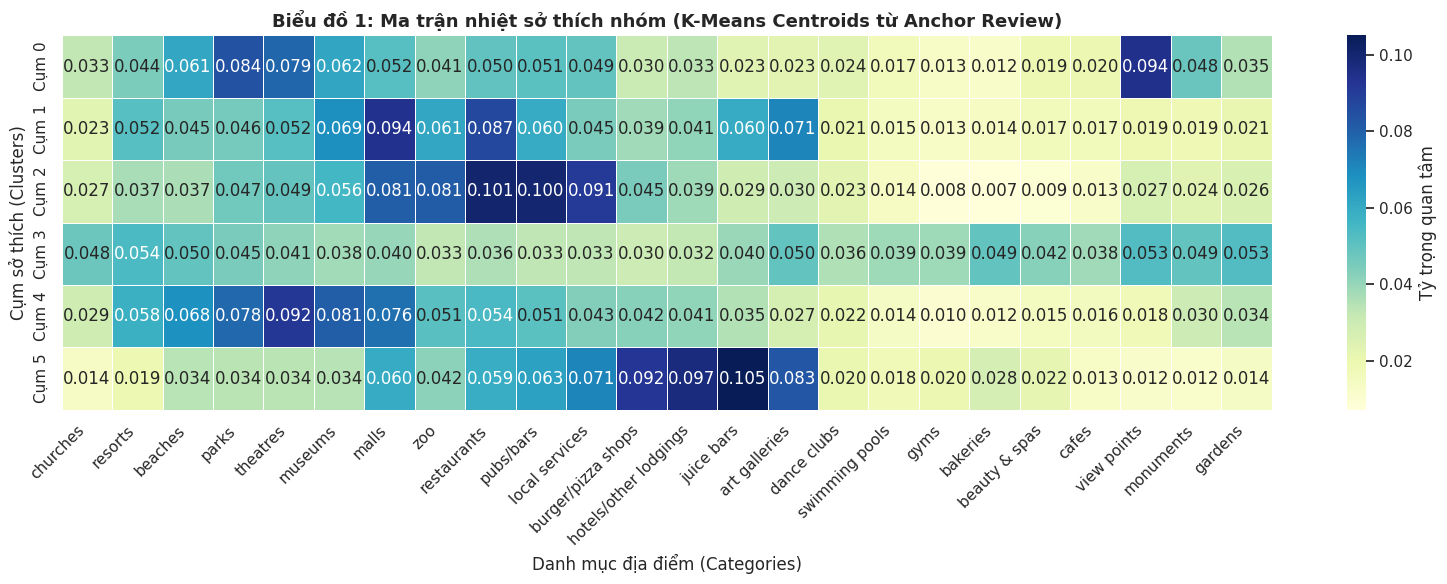

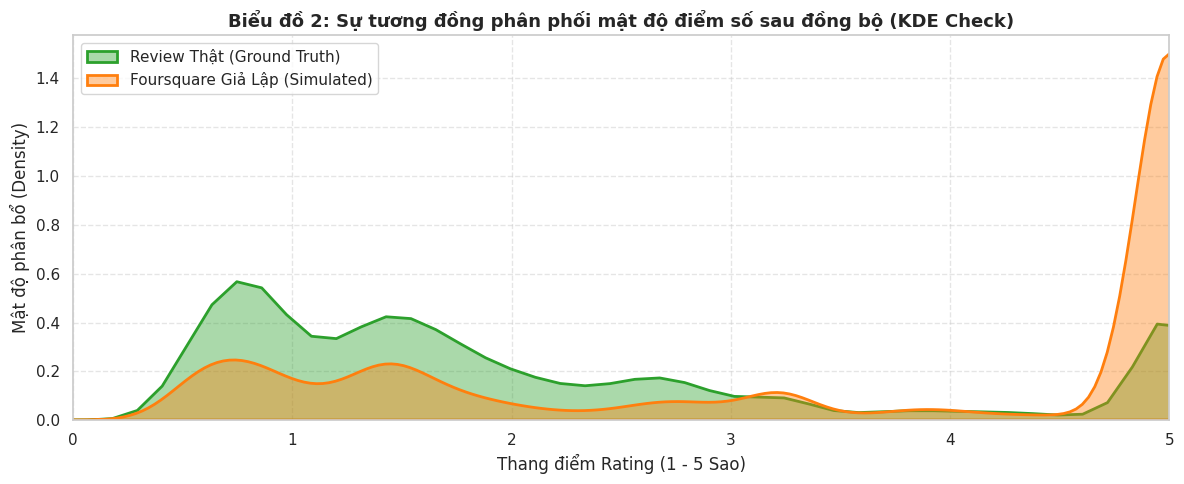

/tmp/ipykernel_2040/2525556086.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_means, x='cluster', y='simulated_rating', palette='Set2', edgecolor='black')


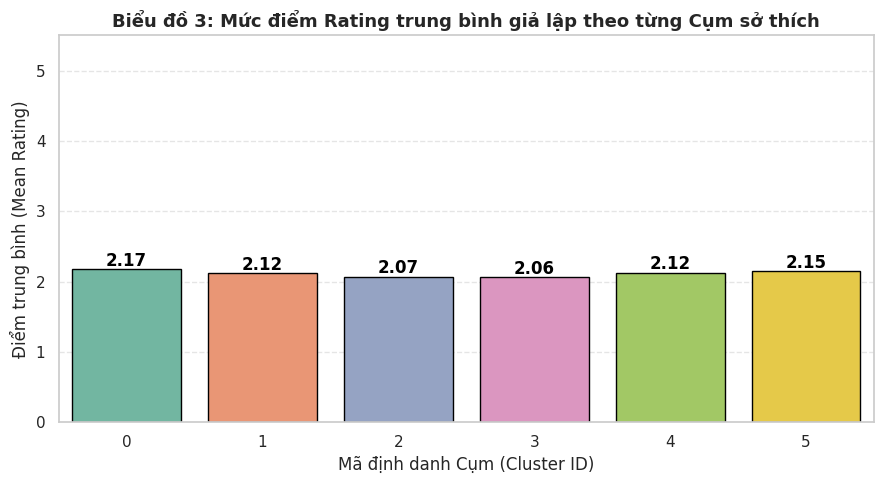

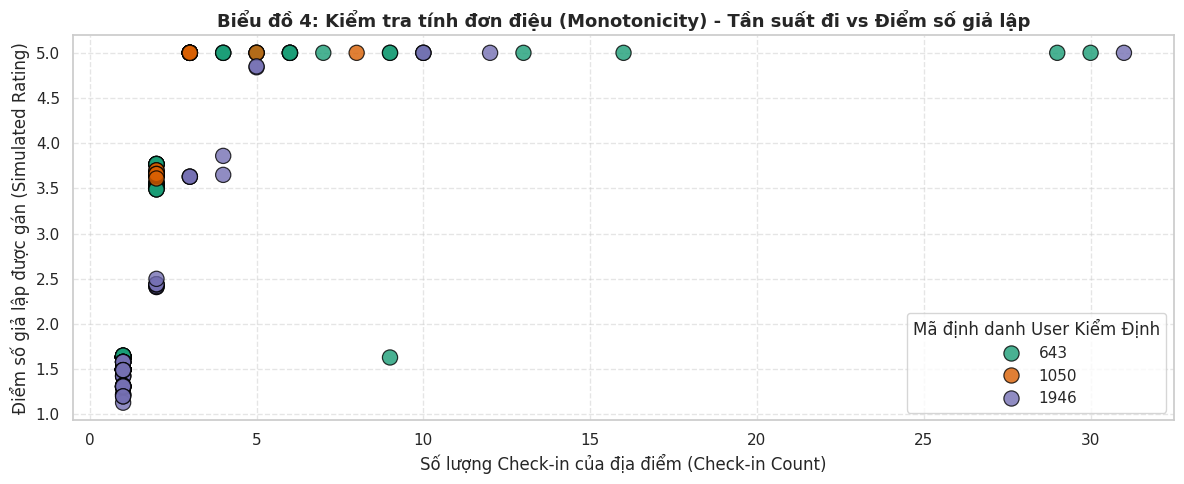

🎯 Đã chọn User tích cực nhất hệ thống sau điền khuyết: USER ID: 822 (1924 check-ins).


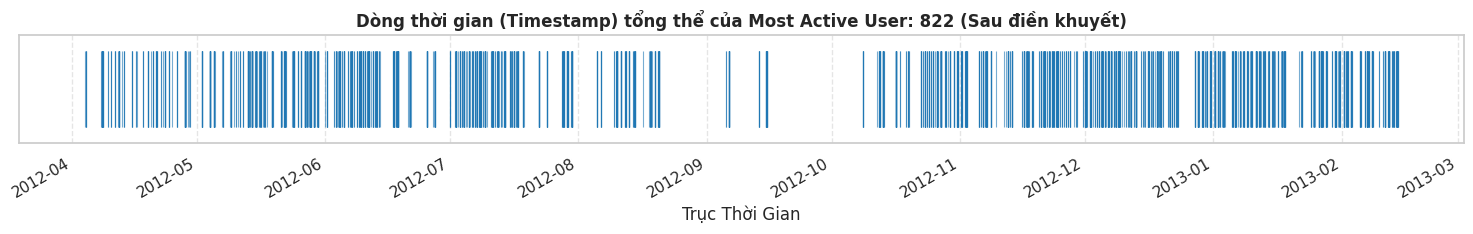

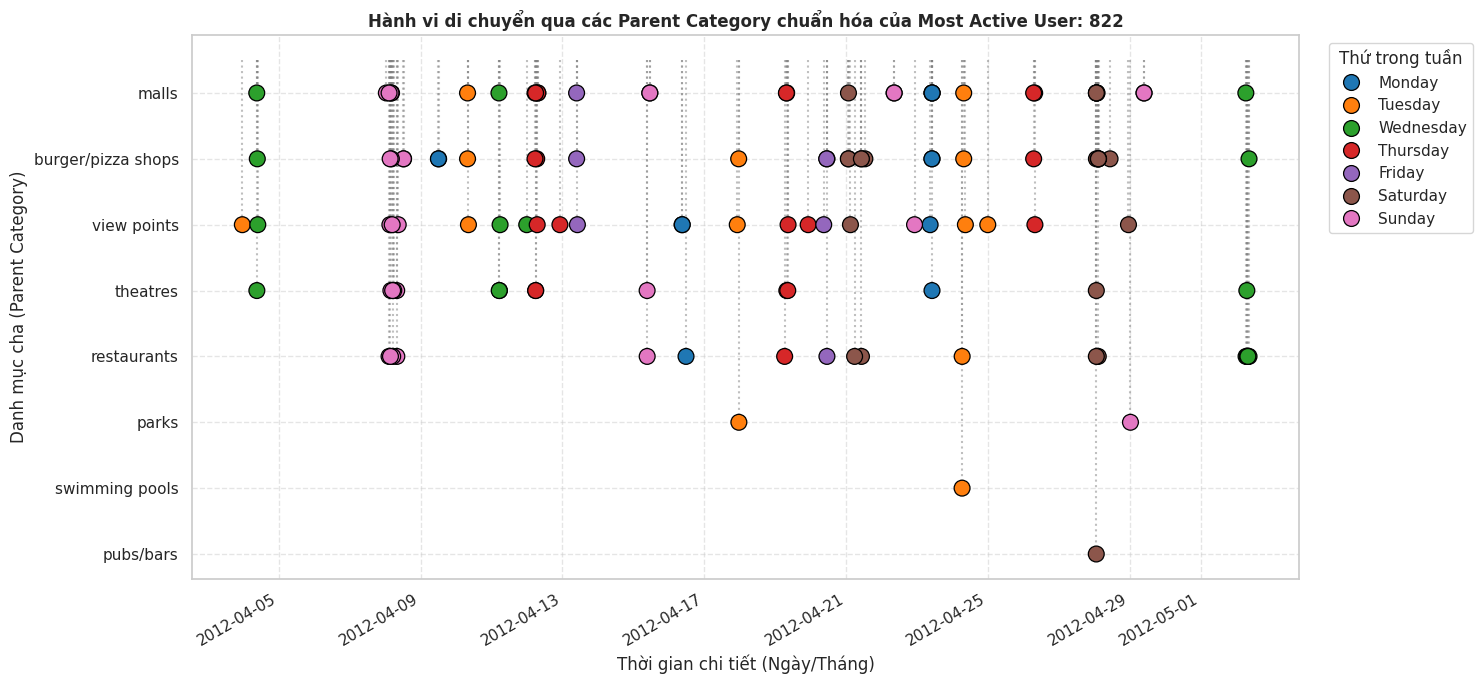

💾 Tất cả các biểu đồ nghiệm thu (từ 06 đến 11) đã được lưu thành công tại: /content/drive/MyDrive/Intro to AI/Plots

📊 BẮT ĐẦU QUY TRÌNH TRỰC QUAN HÓA PHÂN CỤM...
📉 Đang giảm chiều dữ liệu bằng PCA về không gian 2D...
📊 Tỷ lệ thông tin được bảo toàn bởi 2 trục PCA: 37.68% (PC1: 21.7%, PC2: 16.0%)


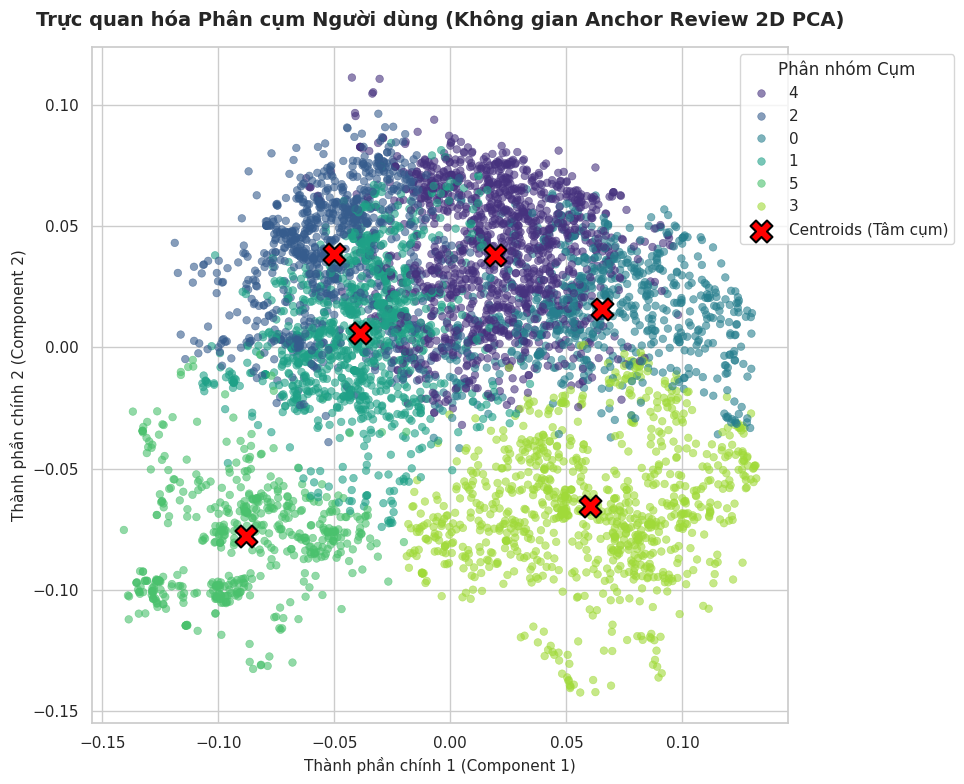

In [7]:
# ==============================================================================
# TRỰC QUAN HÓA NGHIỆM THU CHẤT LƯỢNG SAU ĐIỀN KHUYẾT (POST-IMPUTATION - ĐÃ ĐỒNG BỘ)
# ==============================================================================
def visualize_post_imputation_results(df_review, df_foursquare_final, kmeans_model, n_clusters=4):
    if df_foursquare_final is None or df_foursquare_final.empty:
        print("⚠️ Dữ liệu trống, không thể trực quan hóa!")
        return

    print("\n📊 ĐANG KHỞI TẠO CÁC BIỂU ĐỒ NGHIỆM THU CHẤT LƯỢNG (POST-IMPUTATION)...")
    img_out_dir = '/content/drive/MyDrive/Intro to AI/Plots'
    os.makedirs(img_out_dir, exist_ok=True)

    # FIX CHÍ MẠNG: Chặn cột rác Unnamed: 25 để ma trận Heatmap chuẩn chỉ, không bị lệch shape
    categories = [c for c in df_review.columns if c not in ['userId', 'cluster', 'Unnamed: 25']]

    # --------------------------------------------------------------------------
    # BIỂU ĐỒ 1: MA TRẬN NHIỆT SỞ THÍCH NHÓM (CLUSTER HEATMAP TỪ K-MEANS CENTROIDS)
    # --------------------------------------------------------------------------
    plt.figure(figsize=(16, 6))
    centroids = kmeans_model.cluster_centers_

    # Lấy số lượng cột thực tế tương ứng với số centroids được học (tránh lệch shape 23 vs 24)
    df_centroids = pd.DataFrame(centroids[:, :len(categories)], columns=categories, index=[f'Cụm {i}' for i in range(n_clusters)])

    sns.heatmap(df_centroids, annot=True, cmap='YlGnBu', fmt=".3f", linewidths=.5, cbar_kws={'label': 'Tỷ trọng quan tâm'})
    plt.title('Biểu đồ 1: Ma trận nhiệt sở thích nhóm (K-Means Centroids từ Anchor Review)', fontsize=13, fontweight='bold')
    plt.xlabel('Danh mục địa điểm (Categories)')
    plt.ylabel('Cụm sở thích (Clusters)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(img_out_dir, '06_post_heatmap_kmeans_centroids.png'))
    plt.show()

    # --------------------------------------------------------------------------
    # BIỂU ĐỒ 2: SỰ TƯƠNG ĐỒNG PHÂN PHỐI SAU ĐỒNG BỘ (DISTRIBUTION ALIGNMENT CHECK)
    # --------------------------------------------------------------------------
    plt.figure(figsize=(12, 5))
    review_ratings = df_review[categories].values.flatten()
    review_ratings = review_ratings[~np.isnan(review_ratings) & (review_ratings > 0)]

    sns.kdeplot(review_ratings, label='Review Thật (Ground Truth)', color='#2ca02c', fill=True, alpha=0.4, linewidth=2)
    sns.kdeplot(df_foursquare_final['simulated_rating'], label='Foursquare Giả Lập (Simulated)', color='#ff7f0e', fill=True, alpha=0.4, linewidth=2)

    plt.xlim(0, 5)
    plt.xticks(range(0, 6)) # Hiển thị các vạch chia: 0, 1, 2, 3, 4, 5

    plt.title('Biểu đồ 2: Sự tương đồng phân phối mật độ điểm số sau đồng bộ (KDE Check)', fontsize=13, fontweight='bold')
    plt.xlabel('Thang điểm Rating (1 - 5 Sao)')
    plt.ylabel('Mật độ phân bổ (Density)')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(img_out_dir, '07_post_distribution_alignment_check.png'))
    plt.show()

    # --------------------------------------------------------------------------
    # BIỂU ĐỒ 3: ĐIỂM TRUNG BÌNH THEO TỪNG CỤM (PERSONALIZED RATING VARIANCE)
    # --------------------------------------------------------------------------
    plt.figure(figsize=(9, 5))
    df_unique_items = df_foursquare_final.drop_duplicates(subset=['userId', 'venueId'])
    cluster_means = df_unique_items.groupby('cluster')['simulated_rating'].mean().reset_index()

    sns.barplot(data=cluster_means, x='cluster', y='simulated_rating', palette='Set2', edgecolor='black')

    for index, row in cluster_means.iterrows():
        plt.text(row['cluster'], row['simulated_rating'] + 0.05, f"{row['simulated_rating']:.2f}", color='black', ha="center", fontweight='bold')

    plt.title('Biểu đồ 3: Mức điểm Rating trung bình giả lập theo từng Cụm sở thích', fontsize=13, fontweight='bold')
    plt.xlabel('Mã định danh Cụm (Cluster ID)')
    plt.ylabel('Điểm trung bình (Mean Rating)')
    plt.ylim(0, 5.5)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(img_out_dir, '08_post_cluster_rating_variance.png'))
    plt.show()

    # --------------------------------------------------------------------------
    # BIỂU ĐỒ 4: TƯƠNG QUAN GIỮA TẦN SUẤT CHECK-IN VÀ ĐIỂM SỐ GIẢ LẬP (MONOTONICITY CHECK)
    # --------------------------------------------------------------------------
    plt.figure(figsize=(12, 5))

    df_user_venue_counts = df_foursquare_final.groupby(['userId', 'venueId', 'simulated_rating']).size().reset_index(name='checkin_count')

    unique_users = df_user_venue_counts['userId'].unique()
    sample_users = random.sample(list(unique_users), min(3, len(unique_users)))

    df_samples = df_user_venue_counts[df_user_venue_counts['userId'].isin(sample_users)]

    sns.scatterplot(
        data=df_samples,
        x='checkin_count',
        y='simulated_rating',
        hue='userId',
        palette='Dark2',
        s=120,
        alpha=0.8,
        edgecolor='black',
        zorder=3
    )
    plt.title('Biểu đồ 4: Kiểm tra tính đơn điệu (Monotonicity) - Tần suất đi vs Điểm số giả lập', fontsize=13, fontweight='bold')
    plt.xlabel('Số lượng Check-in của địa điểm (Check-in Count)')
    plt.ylabel('Điểm số giả lập được gán (Simulated Rating)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='Mã định danh User Kiểm Định')
    plt.tight_layout()
    plt.savefig(os.path.join(img_out_dir, '09_post_monotonicity_check.png'))
    plt.show()

    # --------------------------------------------------------------------------
    # BIỂU ĐỒ 5 & 6: KHẢO SÁT CHU KỲ (CHUYỂN SANG MOST ACTIVE USER)
    # --------------------------------------------------------------------------
    user_counts = df_foursquare_final['userId'].value_counts()
    most_active_user = user_counts.index[0]
    user_df = df_foursquare_final[df_foursquare_final['userId'] == most_active_user].copy()

    print(f"🎯 Đã chọn User tích cực nhất hệ thống sau điền khuyết: USER ID: {most_active_user} ({len(user_df)} check-ins).")

    # Barcode Timeline
    plt.figure(figsize=(15, 2.5))
    plt.vlines(user_df['utcTimestamp'], ymin=0, ymax=1, colors='#1f77b4', linewidth=0.8, alpha=0.6)
    plt.title(f'Dòng thời gian (Timestamp) tổng thể của Most Active User: {most_active_user} (Sau điền khuyết)', fontweight='bold')
    plt.xlabel('Trục Thời Gian')
    plt.gca().get_yaxis().set_visible(False)
    plt.ylim(-0.2, 1.2)
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.savefig(os.path.join(img_out_dir, '10_post_most_active_user_barcode.png'))
    plt.show()

    # Chu kỳ tuần trong 1 tháng đầu tiên
    start_date = user_df['utcTimestamp'].min()
    end_date = start_date + pd.Timedelta(days=30)
    month_df = user_df[(user_df['utcTimestamp'] >= start_date) & (user_df['utcTimestamp'] <= end_date)].copy()

    if len(month_df) >= 3:
        month_df['day_of_week'] = month_df['utcTimestamp'].dt.day_name()
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        month_df['day_of_week'] = pd.Categorical(month_df['day_of_week'], categories=day_order, ordered=True)
        month_df = month_df.sort_values('day_of_week')

        plt.figure(figsize=(15, 7))
        sns.scatterplot(
            data=month_df,
            x='utcTimestamp',
            y='parent_category',
            hue='day_of_week',
            palette='tab10',
            s=130,
            marker='o',
            edgecolor='black',
            zorder=3
        )
        plt.vlines(month_df['utcTimestamp'], ymin=-0.5, ymax=month_df['parent_category'], colors='gray', linestyle=':', alpha=0.5)
        plt.title(f'Hành vi di chuyển qua các Parent Category chuẩn hóa của Most Active User: {most_active_user}', fontweight='bold')
        plt.xlabel('Thời gian chi tiết (Ngày/Tháng)')
        plt.ylabel('Danh mục cha (Parent Category)')
        plt.legend(title='Thứ trong tuần', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.gcf().autofmt_xdate()
        plt.tight_layout()
        plt.savefig(os.path.join(img_out_dir, '11_post_most_active_user_temporal_cycle.png'))
        plt.show()
    else:
        print("ℹ️ Dữ liệu tháng đầu của user này quá thưa thớt, bỏ qua biểu đồ chu kỳ tuần.")

    print(f"💾 Tất cả các biểu đồ nghiệm thu (từ 06 đến 11) đã được lưu thành công tại: {img_out_dir}")

def visualize_clustering_results(df_review, kmeans_model):
    print("\n📊 BẮT ĐẦU QUY TRÌNH TRỰC QUAN HÓA PHÂN CỤM...")

    # Lấy danh sách danh mục (bỏ các cột định danh tương tự như trong pipeline)
    categories = [c for c in df_review.columns if c not in ['userId', 'cluster', 'Unnamed: 25']]

    # Chuẩn bị và chuẩn hóa dữ liệu đầu vào giống như khi train KMeans
    review_profiles = df_review[categories].fillna(0).values
    from sklearn.preprocessing import normalize
    review_profiles_norm = normalize(review_profiles, norm='l1', axis=1)

    # Lấy nhãn cụm đã được gán (nếu chưa có cột 'cluster', ta dùng model predict)
    labels = df_review['cluster'] if 'cluster' in df_review.columns else kmeans_model.labels_

    print("📉 Đang giảm chiều dữ liệu bằng PCA về không gian 2D...")
    # Giảm chiều dữ liệu về 2D để vẽ biểu đồ
    pca = PCA(n_components=2, random_state=42)
    profiles_2d = pca.fit_transform(review_profiles_norm)

    # Giảm chiều các tâm cụm (Centroids) để vẽ lên cùng biểu đồ
    centroids_2d = pca.transform(kmeans_model.cluster_centers_)

    # Tạo DataFrame phục vụ việc vẽ đồ thị
    df_vis = pd.DataFrame(profiles_2d, columns=['Component 1', 'Component 2'])
    df_vis['Cluster'] = labels.astype(str) # Chuyển sang string để seaborn hiểu là định tính

    # Tiến hành vẽ
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="whitegrid")

    # Vẽ các điểm dữ liệu của từng cụm
    cluster_colors = sns.color_palette("viridis", n_colors=len(np.unique(labels)))
    sns.scatterplot(
        data=df_vis,
        x='Component 1',
        y='Component 2',
        hue='Cluster',
        palette=cluster_colors,
        alpha=0.6,
        edgecolor=None,
        s=30
    )

    # Vẽ các tâm cụm (Centroids) nổi bật lên
    plt.scatter(
        centroids_2d[:, 0],
        centroids_2d[:, 1],
        marker='X',
        s=250,
        color='red',
        label='Centroids (Tâm cụm)',
        edgecolor='black',
        linewidth=1.5
    )

    # Tối ưu hóa hiển thị
    plt.title('Trực quan hóa Phân cụm Người dùng (Không gian Anchor Review 2D PCA)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Thành phần chính 1 (Component 1)', fontsize=11)
    plt.ylabel('Thành phần chính 2 (Component 2)', fontsize=11)
    plt.legend(title="Phân nhóm Cụm", loc='upper right', bbox_to_anchor=(1.25, 1))
    plt.tight_layout()

    # Hiển thị giải thích tỷ lệ phương sai tích lũy nhằm đánh giá chất lượng giảm chiều
    explained_variance = pca.explained_variance_ratio_
    print(f"📊 Tỷ lệ thông tin được bảo toàn bởi 2 trục PCA: {sum(explained_variance)*100:.2f}% "
          f"(PC1: {explained_variance[0]*100:.1f}%, PC2: {explained_variance[1]*100:.1f}%)")

    plt.show()

# ==============================================================================
# THỰC THI CHUẨN XÁC TÊN BIẾN ĐẦU VÀO
# ==============================================================================
visualize_post_imputation_results(df_review_cleaned, df_final_result, my_kmeans_model, n_clusters=6)
visualize_clustering_results(df_review_cleaned, my_kmeans_model)

## Khai phá dữ liệu

### Khai phá các đặc trưng cần thiết

In [8]:
import os
import numpy as np
import pandas as pd

def export_super_final_from_existing(df_base):
    print("🚀 BẮT ĐẦU TRÍCH XUẤT ĐẶC TRƯNG NÂNG CAO TỪ FILE CÓ SẴN...")

    # Thư mục xuất file siêu final
    out_dir = "/content/drive/MyDrive/Intro to AI/Final_Data"
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, 'foursquare_super_final_features.csv')

    # Copy để tránh ghi đè lên dataframe gốc
    df_base = df_base.copy()

    # Sắp xếp chuỗi thời gian chuẩn xác theo từng user để tính toán các đặc trưng lag chuỗi
    df_base["utcTimestamp"] = pd.to_datetime(df_base["utcTimestamp"])
    df_base = df_base.sort_values(by=["userId", "utcTimestamp"]).reset_index(
        drop=True
    )

    # --------------------------------------------------------------------------
    # 0. ĐỊNH DANH ĐỊA ĐIỂM CHÍNH XÁC (KHÔNG LÀM TRÒN ĐỘ PHÂN GIẢI FLOAT)
    # --------------------------------------------------------------------------
    print(" ├─ 🗺️ Tạo ID địa điểm độc bản (Exact Location Matching)...")
    # Trích xuất toàn bộ tọa độ độc nhất không làm tròn để bảo toàn mật độ đô thị cao
    unique_places = (
        df_base[['latitude', 'longitude']]
        .drop_duplicates()
        .reset_index(drop=True)
    )
    # Gán ID dạng số nguyên (0, 1, 2, ...) tăng dần
    unique_places['placeId'] = unique_places.index

    # Ánh xạ mã placeId ngược lại vào bảng dữ liệu check-in tổng bằng phép merge chính xác
    df_base = pd.merge(df_base, unique_places, on=['latitude', 'longitude'], how='left')
    print(f" └─ [OK] Đã quy hoạch thành công {len(unique_places):,} địa điểm độc bản trên toàn hệ thống.")

    # --------------------------------------------------------------------------
    # 1. KHAI PHÁ NHÓM ĐẶC TRƯNG THỜI GIAN (Temporal & Cyclical Features)
    # --------------------------------------------------------------------------
    # 1.1 Đặc trưng thời gian gốc
    df_base["hour"] = df_base["utcTimestamp"].dt.hour
    df_base["day_of_week"] = df_base["utcTimestamp"].dt.dayofweek
    df_base["is_weekend"] = df_base["day_of_week"].isin([5, 6]).astype(int)

    # 1.2 Biến đổi lượng giác (Cyclical Transformation) để mô hình hiểu tính chu kỳ
    # Chu kỳ của hour là 24 (0 -> 23)
    df_base["hour_sin"] = np.sin(2 * np.pi * df_base["hour"] / 24.0)
    df_base["hour_cos"] = np.cos(2 * np.pi * df_base["hour"] / 24.0)

    # Chu kỳ của day_of_week là 7 (0 -> 6)
    df_base["day_sin"] = np.sin(2 * np.pi * df_base["day_of_week"] / 7.0)
    df_base["day_cos"] = np.cos(2 * np.pi * df_base["day_of_week"] / 7.0)

    # --------------------------------------------------------------------------
    # 2. KHAI PHÁ NHÓM ĐẶC TRƯNG CHUỖI (Sequential/Lag Features)
    # --------------------------------------------------------------------------
    df_base["prev_venueId"] = (
        df_base.groupby("userId")["venueId"].shift(1).fillna("START")
    )
    df_base["prev_parent_category"] = (
        df_base.groupby("userId")["parent_category"].shift(1).fillna("START")
    )

    # Tính khoảng thời gian cách lần check-in trước (đơn vị: phút)
    prev_time = df_base.groupby("userId")["utcTimestamp"].shift(1)
    df_base["minutes_since_last_checkin"] = (
        df_base["utcTimestamp"] - prev_time
    ).dt.total_seconds() / 60.0
    df_base["minutes_since_last_checkin"] = df_base[
        "minutes_since_last_checkin"
    ].fillna(-1)

    # --------------------------------------------------------------------------
    # 3. KHAI PHÁ NHÓM ĐẶC TRƯNG KHÔNG GIAN CÁ NHÂN HÓA (Personalized Spatial)
    # --------------------------------------------------------------------------
    # 3.1 Tọa độ trung tâm vùng lõi hoạt động của từng User (Vị trí mỏ neo)
    user_anchors = (
        df_base.groupby("userId")[["latitude", "longitude"]]
        .median()
        .reset_index()
    )
    user_anchors.columns = ["userId", "user_home_lat", "user_home_lon"]
    df_base = pd.merge(df_base, user_anchors, on="userId", how="left")

    # 3.2 Khoảng cách từ vị trí check-in hiện tại đến vùng lõi của chính user đó
    df_base["dist_from_home"] = np.sqrt(
        (df_base["latitude"] - df_base["user_home_lat"]) ** 2
        + (df_base["longitude"] - df_base["user_home_lon"]) ** 2
    )

    # 3.3 Bán kính dịch chuyển đặc trưng của User (Độ lệch chuẩn khoảng cách)
    user_radius = (
        df_base.groupby("userId")["dist_from_home"]
        .std()
        .reset_index(name="user_mobility_radius")
    )
    user_radius["user_mobility_radius"] = user_radius[
        "user_mobility_radius"
    ].fillna(0)  # Cho user có 1 check-in
    df_base = pd.merge(df_base, user_radius, on="userId", how="left")

    # --------------------------------------------------------------------------
    # 4. QUY HOẠCH VÀ SẮP XẾP THỨ TỰ CÁC CỘT ĐẦU RA CHO ĐẸP
    # --------------------------------------------------------------------------
    ordered_columns = [
        # Nhóm Định danh & Gốc (Original Core)
        "userId",
        "placeId",             # Đưa định danh địa điểm số nguyên mới lên đây bà nhé
        "venueId",
        "venueCategoryId",
        "venueCategory",
        "parent_category",
        "utcTimestamp",
        "timezoneOffset",
        # Nhóm Tọa độ thực tế (Spatial Core)
        "latitude",
        "longitude",
        # Nhóm Kết quả Cross-Domain đã có từ trước của ông
        "cluster",
        "simulated_rating",
        # Nhóm Đặc trưng Thời gian gốc và Chu kỳ mới bóc tách
        "hour",
        "hour_sin",
        "hour_cos",
        "day_of_week",
        "day_sin",
        "day_cos",
        "is_weekend",
        # Nhóm Đặc trưng Chuỗi mới bóc tách
        "prev_venueId",
        "prev_parent_category",
        "minutes_since_last_checkin",
        # Nhóm Đặc trưng Không gian mới bóc tách
        "user_home_lat",
        "user_home_lon",
        "dist_from_home",
        "user_mobility_radius",
    ]

    # Giữ lại các cột phụ khác nếu có phát sinh ngoài danh sách trên
    remaining_cols = [c for c in df_base.columns if c not in ordered_columns]
    final_columns = ordered_columns + remaining_cols

    df_super_final = df_base[final_columns]

    # Xuất thành file CSV
    df_super_final.to_csv(out_path, index=False)

    print("\n==================================================")
    print("🎉 TẠO FILE SIÊU FINAL THÀNH CÔNG (TỪ DATA GỐC)! 🎉")
    print("==================================================")
    print(f"📁 Đường dẫn lưu file: {out_path}")
    print(f"📊 Tổng số dòng dữ liệu: {len(df_super_final):,}")
    print(f"📐 Tổng số đặc trưng (Cột): {len(df_super_final.columns)}")
    print("==================================================")

    return df_super_final


# --- CHẠY THỰC THI ---
# Truyền bảng chứa đặc trưng gốc vào (Ví dụ: df_final_result hoặc df_foursquare_mapped)
df_super_final = export_super_final_from_existing(df_final_result)

# In thử nghiệm thu kết cấu bảng mới
print("\n📸 Cấu trúc 3 dòng đầu của file Siêu Final để kiểm tra:")
df_super_final.head(3)

🚀 BẮT ĐẦU TRÍCH XUẤT ĐẶC TRƯNG NÂNG CAO TỪ FILE CÓ SẴN...
 ├─ 🗺️ Tạo ID địa điểm độc bản (Exact Location Matching)...
 └─ [OK] Đã quy hoạch thành công 43,279 địa điểm độc bản trên toàn hệ thống.

🎉 TẠO FILE SIÊU FINAL THÀNH CÔNG (TỪ DATA GỐC)! 🎉
📁 Đường dẫn lưu file: /content/drive/MyDrive/Intro to AI/Final_Data/foursquare_super_final_features.csv
📊 Tổng số dòng dữ liệu: 197,150
📐 Tổng số đặc trưng (Cột): 26

📸 Cấu trúc 3 dòng đầu của file Siêu Final để kiểm tra:


,userId,placeId,venueId,venueCategoryId,venueCategory,parent_category,utcTimestamp,timezoneOffset,latitude,longitude,...,day_sin,day_cos,is_weekend,prev_venueId,prev_parent_category,minutes_since_last_checkin,user_home_lat,user_home_lon,dist_from_home,user_mobility_radius
0,3,0,4c8a6ed952a98cfa1e912ce9,4bf58dd8d48988d163941735,Park,parks,2012-04-03 22:34:03,540,35.668436,139.600933,...,0.781831,0.623490,0,START,START,-1.000000,35.668436,139.600933,0.000000,0.035599
1,3,1,4b5f1fdff964a5207ba729e3,4bf58dd8d48988d1df931735,BBQ Joint,restaurants,2012-04-04 06:06:49,540,35.666786,139.601786,...,0.974928,-0.222521,0,4c8a6ed952a98cfa1e912ce9,parks,452.766667,35.668436,139.600933,0.001858,0.035599
2,3,2,4cf2066a94feb1f74e401bba,4bf58dd8d48988d1ed941735,Spa / Massage,beauty & spas,2012-04-04 07:10:13,540,35.666287,139.602186,...,0.974928,-0.222521,0,4b5f1fdff964a5207ba729e3,restaurants,63.400000,35.668436,139.600933,0.002488,0.035599


### Trực quan hoá kết quả khai phá

🔬 BẮT ĐẦU ĐÁNH GIÁ ĐẶC TRƯNG TÍCH HỢP GỐC & NÂNG CAO...
⏳ Đang tính toán chỉ số Mutual Information...
⏳ Đang huấn luyện LightGBM Classifier...


/tmp/ipykernel_2040/2256796959.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2040/2256796959.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


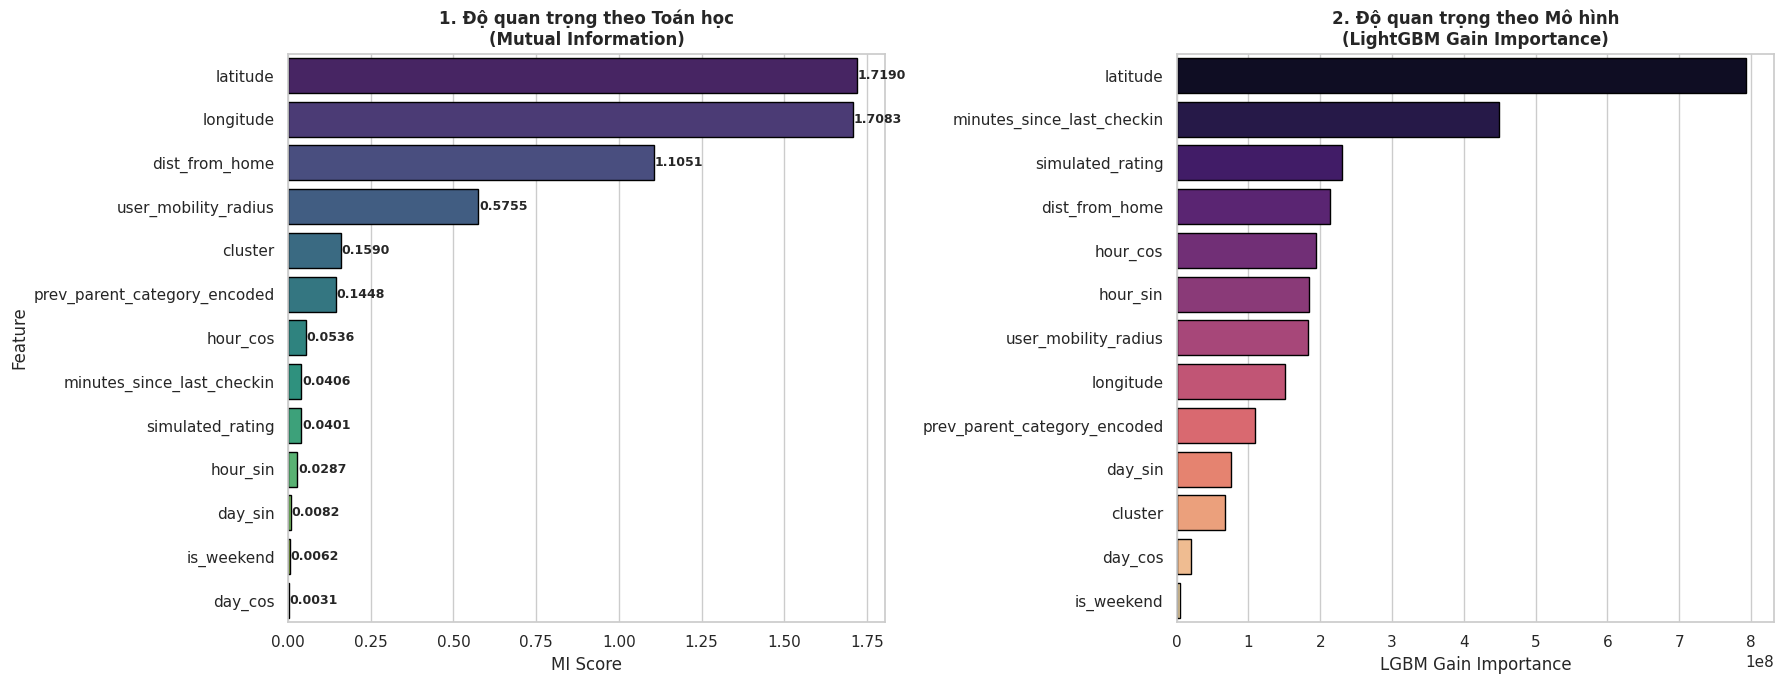

💾 Biểu đồ nghiệm thu tích hợp đã được lưu thành công!


In [9]:
def evaluate_with_original_features(df_enriched):
    print("🔬 BẮT ĐẦU ĐÁNH GIÁ ĐẶC TRƯNG TÍCH HỢP GỐC & NÂNG CAO...")

    df_clean = df_enriched.copy()

    # 1. Định nghĩa tập các đặc trưng hợp lệ (Đã cập nhật các biến sin/cos đồng bộ)
    # Loại bỏ hoàn toàn: userId, venueId, venueCategoryId, venueCategory, utcTimestamp
    X_cols = [
        # Nhóm Đặc trưng thời gian dạng Chu kỳ (Cyclical)
        "hour_sin",
        "hour_cos",
        "day_sin",
        "day_cos",
        "is_weekend",
        # Nhóm Đặc trưng chuỗi & Không gian nâng cao
        "minutes_since_last_checkin",
        "dist_from_home",
        "user_mobility_radius",
        # Nhóm Đặc trưng gốc (Hợp lệ)
        "latitude",
        "longitude",
        "simulated_rating",
        "cluster",
    ]

    # Mã hóa các biến định tính cần thiết (Target variable)
    le_target = LabelEncoder()
    y = le_target.fit_transform(df_clean["parent_category"])

    # Bổ sung thêm biến lag chuỗi liền trước đã mã hóa
    le_prev_cat = LabelEncoder()
    df_clean["prev_parent_category_encoded"] = le_prev_cat.fit_transform(
        df_clean["prev_parent_category"]
    )
    X_cols.append("prev_parent_category_encoded")

    # Trích xuất ma trận đặc trưng X
    X = df_clean[X_cols].values

    # Thư mục lưu ảnh biểu đồ
    img_out_dir = "/content/drive/MyDrive/Intro to AI/Plots"
    os.makedirs(img_out_dir, exist_ok=True)

    # --- PHƯƠNG PHÁP 1: MUTUAL INFORMATION ---
    print("⏳ Đang tính toán chỉ số Mutual Information...")
    mi_scores = mutual_info_classif(X, y, random_state=42)
    df_mi = pd.DataFrame({"Feature": X_cols, "MI Score": mi_scores}).sort_values(
        by="MI Score", ascending=False
    )

    # --- PHƯƠNG PHÁP 2: LIGHTGBM FEATURE IMPORTANCE ---
    print("⏳ Đang huấn luyện LightGBM Classifier...")
    lgb_model = LGBMClassifier(
        n_estimators=100, learning_rate=0.1, random_state=42, verbosity=-1
    )
    lgb_model.fit(X, y)
    lgb_importance = lgb_model.booster_.feature_importance(
        importance_type="gain"
    )
    df_lgb = pd.DataFrame(
        {"Feature": X_cols, "LGBM Gain Importance": lgb_importance}
    ).sort_values(by="LGBM Gain Importance", ascending=False)

    # --- TRỰC QUAN HÓA BẰNG ĐỒ THỊ SIDE-BY-SIDE ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.set_theme(style="whitegrid")

    # Biểu đồ 1: Mutual Information
    sns.barplot(
        data=df_mi,
        x="MI Score",
        y="Feature",
        ax=axes[0],
        palette="viridis",
        edgecolor="black",
    )
    axes[0].set_title(
        "1. Độ quan trọng theo Toán học\n(Mutual Information)",
        fontsize=12,
        fontweight="bold",
    )

    for index, row in df_mi.reset_index().iterrows():
        axes[0].text(
            row["MI Score"] + 0.002,
            index,
            f"{row['MI Score']:.4f}",
            va="center",
            fontweight="bold",
            fontsize=9,
        )

    # Biểu đồ 2: LightGBM
    sns.barplot(
        data=df_lgb,
        x="LGBM Gain Importance",
        y="Feature",
        ax=axes[1],
        palette="magma",
        edgecolor="black",
    )
    axes[1].set_title(
        "2. Độ quan trọng theo Mô hình\n(LightGBM Gain Importance)",
        fontsize=12,
        fontweight="bold",
    )
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.savefig(
        os.path.join(img_out_dir, "13_integrated_feature_importance.png")
    )
    plt.show()

    print(f"💾 Biểu đồ nghiệm thu tích hợp đã được lưu thành công!")
    return df_mi, df_lgb

df_mi_res, df_lgb_res = evaluate_with_original_features(df_super_final)